In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv("netflix_titles.csv")

In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
df.shape

(8807, 12)

In [5]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [7]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df_clean = df.copy()

In [10]:
df_clean['director'] = df_clean['director'].fillna('Unknown')
df_clean['cast'] = df_clean['cast'].fillna('Unknown')
df_clean['country'] = df_clean['country'].fillna('Unknown')

df_clean.dropna(subset=['date_added', 'rating', 'duration'], inplace=True)

In [11]:
df_clean.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


In [12]:
df_clean.shape


(8790, 12)

## Question 1: What is the distribution of Movies and TV Shows on Netflix?

In [13]:
df_clean['type'].value_counts()

,count
type,
Movie,6126
TV Show,2664


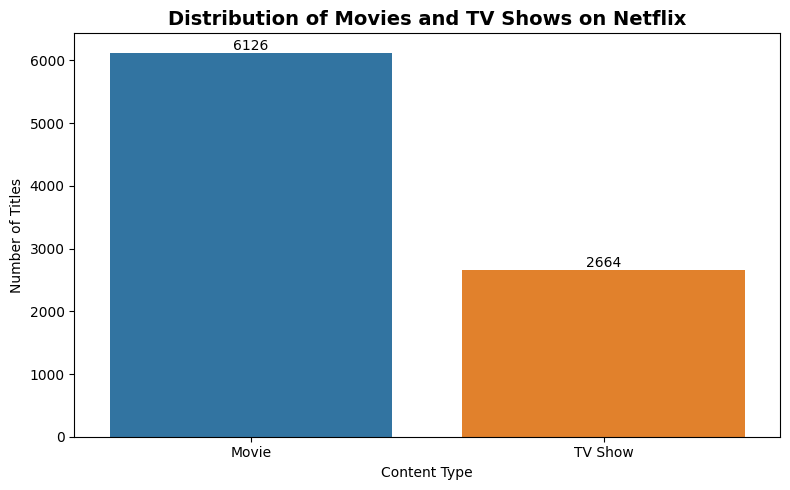

In [14]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df_clean,
    x='type',
    hue='type',
    legend=False
)

plt.title('Distribution of Movies and TV Shows on Netflix', fontsize=14, fontweight='bold')
plt.xlabel('Content Type')
plt.ylabel('Number of Titles')

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [15]:
content_counts = df_clean['type'].value_counts()

movie_count = content_counts['Movie']
tv_count = content_counts['TV Show']

total = movie_count + tv_count

movie_percentage = (movie_count / total) * 100
tv_percentage = (tv_count / total) * 100

print(f"Movies: {movie_percentage:.2f}%")
print(f"TV Shows: {tv_percentage:.2f}%")

Movies: 69.69%
TV Shows: 30.31%


### Key Finding

The dataset shows that Netflix has more movies than TV shows. Out of 8,790 titles, 6,126 are movies and 2,664 are TV shows.

Movies make up around 70% of the content available on Netflix. This indicates that Netflix focuses more on providing movie content to its users.

Overall, movies are the most common type of content on the platform and form the largest part of Netflix's library.


##Question 2: Which countries contribute the most content to Netflix?

In [16]:
country_counts = df_clean[df_clean['country'] != 'Unknown']['country'].value_counts().head(10)

country_counts

,count
country,
United States,2809
India,972
United Kingdom,418
Japan,243
South Korea,199
Canada,181
Spain,145
France,124
Mexico,110


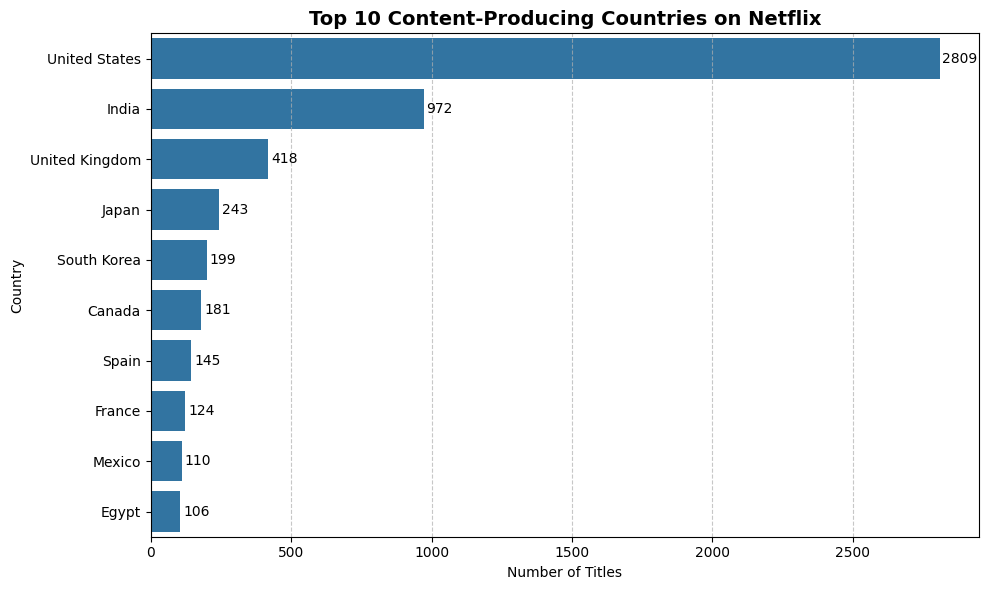

In [17]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=country_counts.values,
    y=country_counts.index
)

plt.title('Top 10 Content-Producing Countries on Netflix',
          fontsize=14,
          fontweight='bold')

plt.xlabel('Number of Titles')
plt.ylabel('Country')

# Add values on bars
for i, v in enumerate(country_counts.values):
    plt.text(v + 10, i, str(v), va='center')

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [18]:
country_percentage = (2809 / 8790) * 100

print(f"Key Insight: Nearly one-third ({country_percentage:.2f}%) of Netflix's content comes from the United States.")

Key Insight: Nearly one-third (31.96%) of Netflix's content comes from the United States.


### Key Finding

The United States is the largest contributor to Netflix's content library, with 2,809 titles. India ranks second with 972 titles, followed by the United Kingdom, Japan, and South Korea.

The United States alone contributes approximately 31.96% of the total content in the dataset. This shows the significant role of American content on Netflix. At the same time, countries such as India, Japan, and South Korea also contribute a notable amount of content, highlighting Netflix's global reach.

## Question 3: How has Netflix content changed over the years?

In [19]:
content_by_year = df_clean['release_year'].value_counts().sort_index()
content_by_year.tail(15)

,count
release_year,
2007,88
2008,135
2009,152
2010,192
2011,185
2012,236
2013,286
2014,352
2015,555


In [20]:
content_by_year

,count
release_year,
1925,1
1942,2
1943,3
1944,3
1945,4
...,...
2017,1030
2018,1146
2019,1030


In [21]:
content_2000 = content_by_year[content_by_year.index >= 2000]

content_2000

,count
release_year,
2000,37
2001,45
2002,51
2003,59
2004,64
2005,80
2006,96
2007,88
2008,135


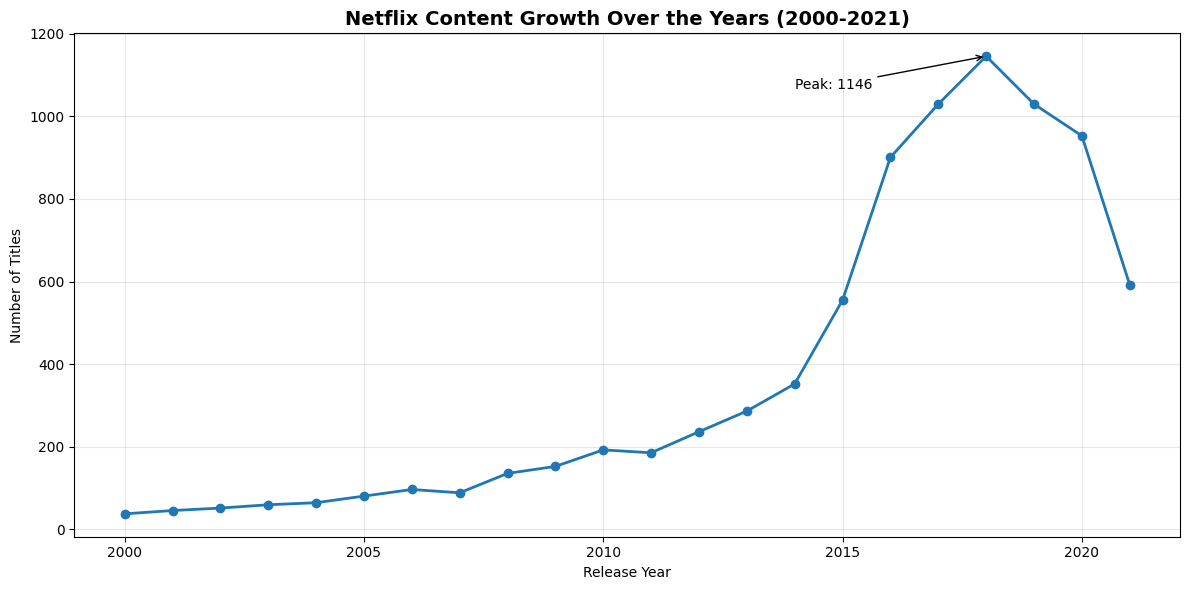

In [22]:
plt.figure(figsize=(12,6))

plt.plot(
    content_2000.index,
    content_2000.values,
    marker='o',
    linewidth=2
)

peak_year = content_2000.idxmax()
peak_value = content_2000.max()

plt.annotate(
    f'Peak: {peak_value}',
    xy=(peak_year, peak_value),
    xytext=(peak_year-4, peak_value-80),
    arrowprops=dict(arrowstyle='->')
)

plt.title(
    'Netflix Content Growth Over the Years (2000-2021)',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Release Year')
plt.ylabel('Number of Titles')

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
peak_year = content_2000.idxmax()
peak_value = content_2000.max()

print(f"Netflix reached its highest content release count in {peak_year} with {peak_value} titles.")

Netflix reached its highest content release count in 2018 with 1146 titles.


### Additional Insight

Netflix released the highest number of titles in 2018, with 1,146 movies and TV shows. This was the year when Netflix was adding a large amount of content to attract more viewers around the world.

### Key Finding

Netflix added more and more content every year, especially after 2015. The platform saw its biggest growth in 2018, when it released 1,146 titles.

After 2018, the number of releases began to fall. Even though Netflix continued adding new content, the growth was not as strong as before.

This trend shows how Netflix rapidly expanded its library to reach a larger audience and later shifted towards a slower growth phase.

## Question 4: What are the most common content ratings on Netflix?

In [24]:
df_clean['rating'].value_counts().head(10)

,count
rating,
TV-MA,3205
TV-14,2157
TV-PG,861
R,799
PG-13,490
TV-Y7,333
TV-Y,306
PG,287
TV-G,220


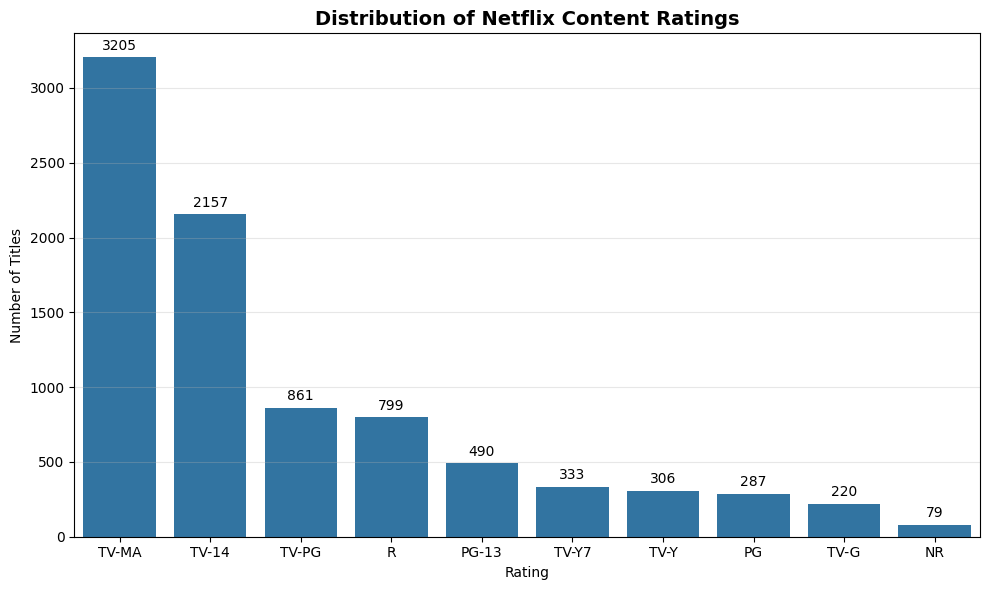

In [25]:
rating_counts = df_clean['rating'].value_counts().head(10)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=rating_counts.index,
    y=rating_counts.values
)

plt.title(
    'Distribution of Netflix Content Ratings',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Rating')
plt.ylabel('Number of Titles')

for i, value in enumerate(rating_counts.values):
    ax.text(i, value + 50, str(value), ha='center')

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [26]:
top_rating = rating_counts.idxmax()
top_rating_count = rating_counts.max()

print(f"The most common rating on Netflix is {top_rating} with {top_rating_count} titles.")

The most common rating on Netflix is TV-MA with 3205 titles.


### Additional Insight

TV-MA is the most common content rating on Netflix, with more than 3,200 titles. This rating is intended for mature audiences and indicates that a large portion of Netflix's content is designed for adult viewers.

### Key Finding

The chart shows that TV-MA and TV-14 are the most common ratings on Netflix.

This tells us that Netflix has more content for adults and teenagers than for young children.

Overall, most of Netflix's content is aimed at older audiences.

## Question 5: What are the most popular genres on Netflix?

In [27]:
df_clean['listed_in'].head()

,listed_in
0,Documentaries
1,"International TV Shows, TV Dramas, TV Mysteries"
2,"Crime TV Shows, International TV Shows, TV Act..."
3,"Docuseries, Reality TV"
4,"International TV Shows, Romantic TV Shows, TV ..."


In [28]:
genres = df_clean['listed_in'].str.split(', ', expand=True).stack()

genre_counts = genres.value_counts()

genre_counts.head(10)

,count
International Movies,2752
Dramas,2426
Comedies,1674
International TV Shows,1349
Documentaries,869
Action & Adventure,859
TV Dramas,762
Independent Movies,756
Children & Family Movies,641
Romantic Movies,616


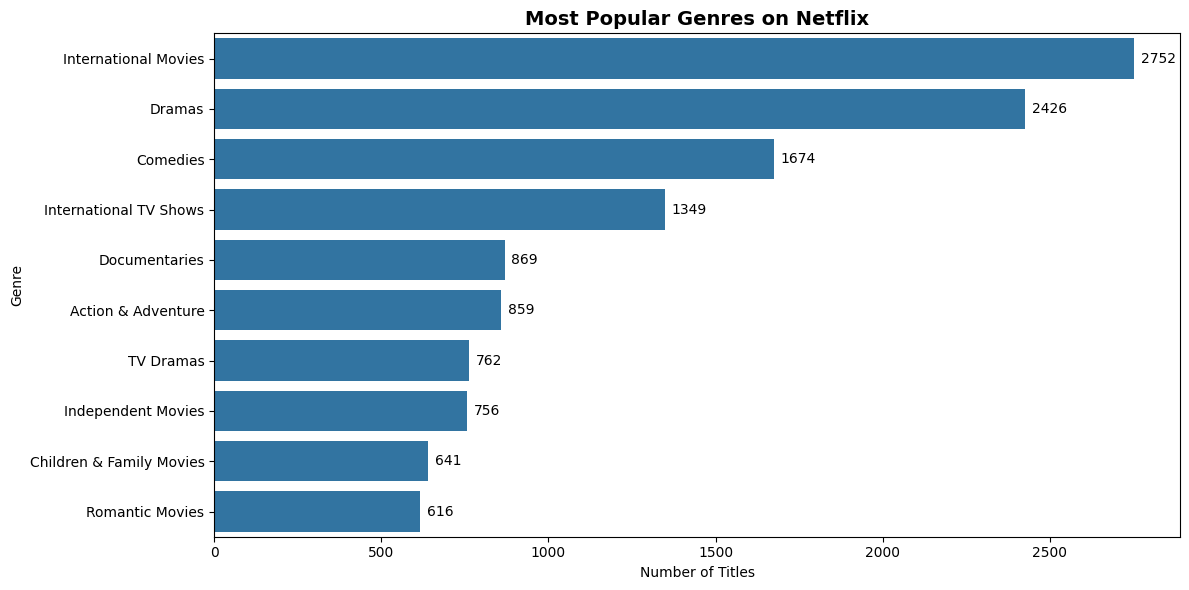

In [29]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=genre_counts.head(10).values,
    y=genre_counts.head(10).index
)

plt.title(
    'Most Popular Genres on Netflix',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Number of Titles')
plt.ylabel('Genre')

for i, value in enumerate(genre_counts.head(10).values):
    ax.text(value + 20, i, str(value), va='center')

plt.tight_layout()
plt.show()

In [30]:
top_genre = genre_counts.idxmax()
top_genre_count = genre_counts.max()

print(f"International Movies is the most popular genre on Netflix, with {top_genre_count} titles.")

International Movies is the most popular genre on Netflix, with 2752 titles.


### Additional Insight

International Movies is the most popular genre on Netflix, with more than 2,700 titles. This shows that Netflix offers a large collection of content from different countries around the world.

### Key Finding

The chart shows that International Movies, Dramas, and Comedies are the most common genres on Netflix.

This means that Netflix provides a wide variety of content for different types of viewers. Drama and comedy content are especially popular, while international content plays a major role in Netflix's library.

Overall, Netflix focuses on offering content that appeals to audiences from different countries and cultures.

## Question 6: Which directors have the most content on Netflix?

In [31]:
df_clean['director'].value_counts().head(10)

,count
director,
Unknown,2621
Rajiv Chilaka,19
"Raúl Campos, Jan Suter",18
Suhas Kadav,16
Marcus Raboy,16
Jay Karas,14
Cathy Garcia-Molina,13
Jay Chapman,12
Youssef Chahine,12


In [32]:
director_counts = df_clean[df_clean['director'] != 'Unknown']['director'].value_counts().head(10)

director_counts

,count
director,
Rajiv Chilaka,19
"Raúl Campos, Jan Suter",18
Suhas Kadav,16
Marcus Raboy,16
Jay Karas,14
Cathy Garcia-Molina,13
Jay Chapman,12
Youssef Chahine,12
Martin Scorsese,12


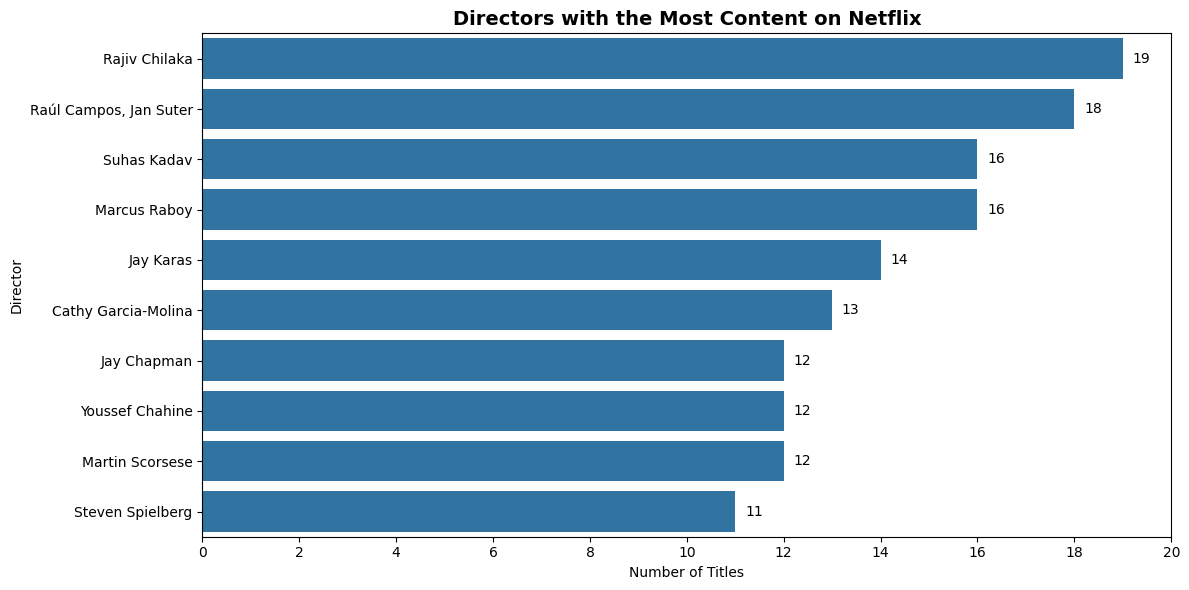

In [35]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=director_counts.values,
    y=director_counts.index
)

plt.title(
    'Directors with the Most Content on Netflix',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Number of Titles')
plt.ylabel('Director')

for i, value in enumerate(director_counts.values):
    ax.text(value + 0.2, i, str(value), va='center')

plt.xticks(range(0, 21, 2))
plt.tight_layout()
plt.show()

In [34]:
top_director = director_counts.idxmax()
top_director_count = director_counts.max()

print(f"{top_director} has the highest number of titles on Netflix, with {top_director_count} titles.")

Rajiv Chilaka has the highest number of titles on Netflix, with 19 titles.


### Additional Insight

Rajiv Chilaka is the director with the most content on Netflix in this dataset, with 19 titles. This shows that some directors have contributed multiple movies and shows to the platform.

### Key Finding

Rajiv Chilaka has the highest number of titles in the dataset, with 19 releases on Netflix.

The difference between the top directors is relatively small, showing that Netflix works with a wide range of directors rather than relying heavily on a few individuals.

This helps Netflix offer a diverse collection of content to its viewers.

##Question 7: How has Netflix content been added over time?

In [39]:
df_clean['date_added'] = pd.to_datetime(
    df_clean['date_added'],
    errors='coerce'
)

df_clean['year_added'] = df_clean['date_added'].dt.year

content_added = df_clean['year_added'].value_counts().sort_index()

content_added.tail(10)

,count
year_added,
2012.0,3
2013.0,10
2014.0,23
2015.0,73
2016.0,415
2017.0,1161
2018.0,1624
2019.0,1999
2020.0,1878


In [40]:
df_clean['date_added'].isnull().sum()

np.int64(88)

In [41]:
content_added.index = content_added.index.astype(int)
content_added

,count
year_added,
2008,2
2009,2
2010,1
2011,13
2012,3
2013,10
2014,23
2015,73
2016,415


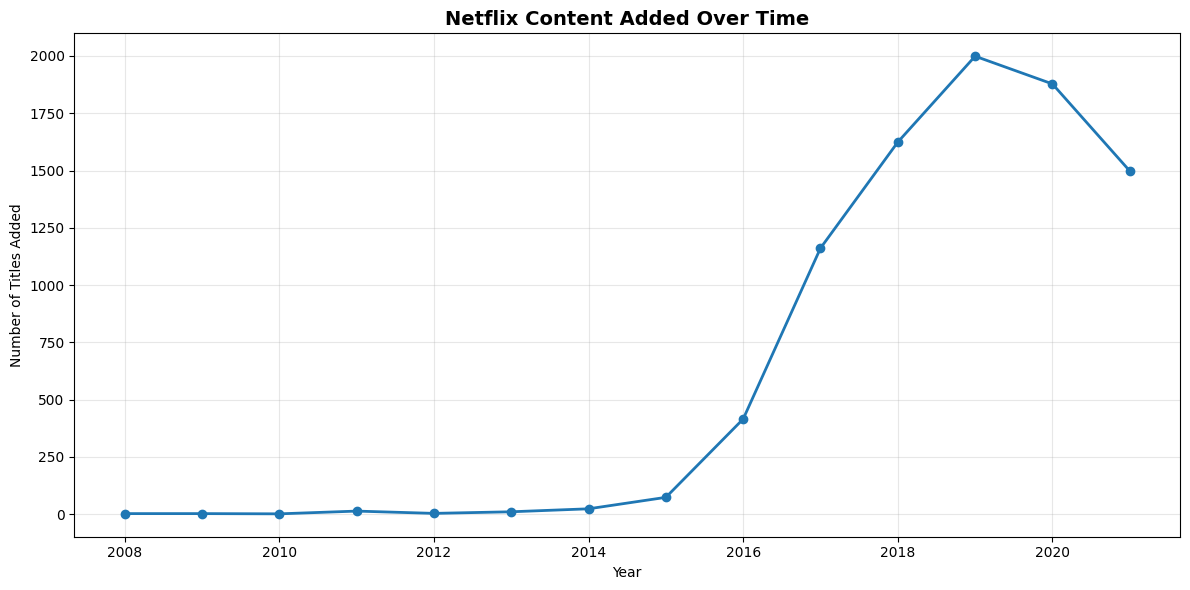

In [42]:
plt.figure(figsize=(12,6))

plt.plot(
    content_added.index,
    content_added.values,
    marker='o',
    linewidth=2
)

plt.title(
    'Netflix Content Added Over Time',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Year')
plt.ylabel('Number of Titles Added')

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [43]:
peak_year = content_added.idxmax()
peak_value = content_added.max()

print(
    f"Netflix added the highest number of titles in {peak_year}, with {peak_value} titles."
)

Netflix added the highest number of titles in 2019, with 1999 titles.


### Additional Insight

Netflix added the highest number of titles in 2019, with 1,999 titles. This was the period when Netflix was rapidly expanding its content library.

### Key Finding

The number of titles added to Netflix increased rapidly after 2015.

The highest number of titles was added in 2019. After that, the number of additions started to decrease, although Netflix continued adding a large amount of content every year.

Overall, the data shows that Netflix experienced major growth between 2016 and 2019.

# Final Conclusion

In this project, I analyzed Netflix content using Python and data visualization tools.

The analysis showed that movies make up a larger portion of Netflix's library than TV shows. The United States contributes the most content, while international movies and TV shows are also an important part of the platform.

I found that Netflix added a large amount of content between 2016 and 2019, with 2019 being the year when the most titles were added. The analysis also showed that most Netflix content is aimed at adults and teenagers.

Overall, this project helped me understand how to clean data, analyze trends, create visualizations, and find useful insights from real-world data.

# Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Google Colab